<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# III. Materiais elásticos
## Lei de Hooke. Parte I
## Problema 3 <a name="PIII63"></a>

Um quadrado de largura unitária, desenhado numa chapa metálica deforma-se de acordo com o seguinte campo de deslocamentos (Origem dos eixos no canto inferior esquerdo):

\begin{equation*}
\begin{cases}
u &=& -0,002x - 0,003y  \\
v &=& 0,001x + 0,0025y  \\
w &=& 0 \\
\end{cases} \quad\textrm{[mm]}
\end{equation*}

Calcule, sabendo que o metal obedece à lei de Hooke e que $E = 200$ GPa e $\nu = 0,3$:

[a)](#A)  O tensor das extensões.

[b)](#B)  As tensões principais.

## Resolução

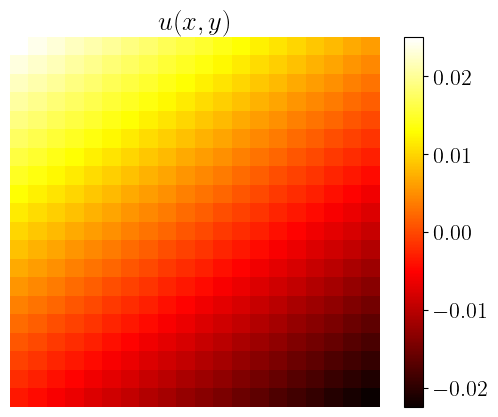

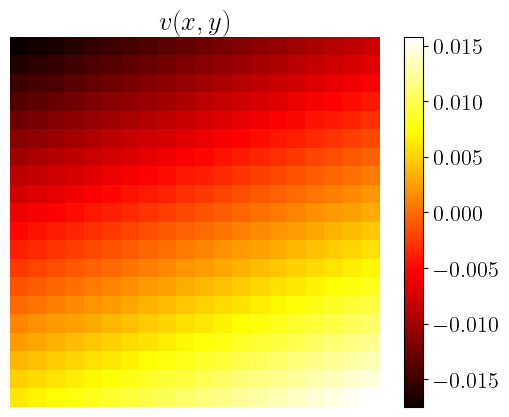

In [39]:
import numpy as np
from sympy import diff
from sympy import symbols
import matplotlib.pyplot as plt
from pylab import cm,imshow,colorbar,title

from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
# rc('text', usetex=True)

u, v, w, x, y, z = symbols('u v w x y z')

a100 = -0.002; a010 = -0.003
b100 = 0.001; b010 = 0.0025
c000 = 0.0

def u(x,y): return a100*x + a010*y
def v(x,y): return b100*x + b010*y
def w(): return c000

xQ = np.arange(-5.,5.,.5); yQ = xQ; zQ = xQ
X,Y = np.meshgrid(xQ, yQ) # grid of point

def PlotFig(X,Y,Z,stg):
    plt.figure(111)
    colorbar(imshow(Z,cmap=cm.hot))
    title(stg), plt.axis('off')
    plt.show()

PlotFig(X,Y,u(X,Y),r'$u(x,y)$')
PlotFig(X,Y,v(X,Y),r'$v(x,y)$')

#### a) O tensor das extensões. <a name="A"></a>

([enunciatum](#PIII63))

As componentes cartesianas da matriz do tensor das deformações infinitésimais pode ser obtido a partir do campo de deslocamentos através das seguintes relações:

\begin{equation*}
\varepsilon_{ij} = \frac{1}{2}\left( \frac{\partial u_i}{\partial x_j}
+ \frac{\partial u_j}{\partial x_i} \right)
\end{equation*}

Explicitamente, têm-se:

\begin{equation*}
\begin{cases}
\varepsilon_{xx} &= \frac{\partial u}{\partial x} \\
\varepsilon_{yy} &= \frac{\partial v}{\partial y} \\
\varepsilon_{zz} &= \frac{\partial w}{\partial z} \\
\varepsilon_{xy} &= \frac{1}{2}\left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)  = \frac{1}{2}\gamma_{xy}\\
\varepsilon_{yz} &= \frac{1}{2}\left( \frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right)  = \frac{1}{2} \gamma_{yz}\\
\varepsilon_{xz} &= \frac{1}{2}\left( \frac{\partial u}{\partial z} + \frac{\partial w}{\partial x} \right) = \frac{1}{2} \gamma_{xz}\\
\end{cases}
\end{equation*}

In [40]:
u1 = u(x,y)
v1 = v(x,y)
w1 = w()

# componentes cartesianas da matriz das deformações
exx = diff(u1, x)
print(f'\nexx = du\\dx : {exx:.3e}')
eyy = diff(v1, y)
print(f'eyy = dv\\dy : {eyy}')
ezz = diff(w1, z)
print(f'ezz = dw\\dz : {ezz}')
exy  = 0.5*(diff(u1, y) + diff(v1, x) )
print(f'exy = 1\\2 gxy = 1\\2(du\\dy+dv\\dx)  : {exy:.3e}')
exz  = 0.5*(diff(u1, z) + diff(w1, x) )
print(f'exz = 1\\2 gxz = 1\\2(du\\dz+dw\\dx)  : {exz}')
eyz  = 0.5*(diff(v1, z) + diff(w1, y) )
print(f'eyz = 1\\2 gxy = 1\\2(dv\\dz+dw\\dy)  : {eyz}')

print('\nMatriz das deformações, [D] :')
def mD(exx,exy,exz,eyy,eyz,ezz):
    return np.array([[exx,exy,exz],[exy,eyy,eyz],[exz,eyz,ezz]])

mD0 = mD(exx,exy,exz,eyy,eyz,ezz)
print('[D] =\n',mD0)

exxP = mD0[0,0]
eyyP = mD0[1,1]
exyP = mD0[0,1]
gxyP = 2*exyP


exx = du\dx : -2.000e-3
eyy = dv\dy : 0.00250000000000000
ezz = dw\dz : 0
exy = 1\2 gxy = 1\2(du\dy+dv\dx)  : -1.000e-3
exz = 1\2 gxz = 1\2(du\dz+dw\dx)  : 0
eyz = 1\2 gxy = 1\2(dv\dz+dw\dy)  : 0

Matriz das deformações, [D] :
[D] =
 [[-0.00200000000000000 -0.00100000000000000 0]
 [-0.00100000000000000 0.00250000000000000 0]
 [0 0 0]]


A matriz das deformações vem dada por:

\begin{equation*}
\begin{aligned}
\underline{\underline{\varepsilon}} \equiv [\varepsilon] \equiv \varepsilon_{ij}
&=
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz}\\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \varepsilon_{zy} & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
\varepsilon_{xx} & \gamma_{xy}/2 & \gamma_{xz}/2 \\
\gamma_{yx}/2 & \varepsilon_{yy} & \gamma_{yz}/2 \\
\gamma_{zx}/2 & \gamma_{yz}/2 & \varepsilon_{zz} \\
\end{bmatrix} \\
&=
\begin{bmatrix}
\frac{\partial u}{\partial x}
& \frac{1}{2}\left(\frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)
& \frac{1}{2}\left(\frac{\partial u}{\partial z} + \frac{\partial w}{\partial x} \right) \\
\frac{1}{2}\left(\frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} \right)
& \frac{\partial v}{\partial y}
& \frac{1}{2}\left(\frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right) \\
\frac{1}{2}\left(\frac{\partial w}{\partial x} + \frac{\partial u}{\partial z} \right)
& \frac{1}{2}\left(\frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right)
& \frac{\partial w}{\partial z} \\
\end{bmatrix} \\
&=\begin{bmatrix}
-0.002 & -0.001 & 0\\
-0.001 & 0.0025 & 0\\
0 & 0 & 0\\
\end{bmatrix}
\end{aligned}
\end{equation*}

Pelo que $\varepsilon_{zz} = 0$ é uma deformação principal.

**Da lei de Hooke para um material isotrópico.**

Para um material isotrópico a lei de Hooke tridimensional vem expressa por:

\begin{equation*}
\varepsilon_{ij} = \frac{1}{E}[(1+\nu)\sigma_{ij} - \nu\delta_{ij}\sigma_{kk}]
= \frac{1}{2\mu} \sigma_{ij} - \frac{\lambda}{2\mu(3\lambda+2\mu)}\delta_{ij}\sigma_{kk}
= \frac{1}{2\mu} \sigma_{ij} - \frac{\nu}{E}\delta_{ij}\sigma_{kk}
\end{equation*}

ou reciprocamente,

\begin{equation*}
\sigma_{ij} = \frac{E}{1+\nu}\varepsilon_{ij} + \frac{\nu E}{(1+\nu)(1-2\nu)}\varepsilon_{kk}\delta_{ij}
= 2\mu \varepsilon_{ij} + \lambda\varepsilon_{kk}\delta_{ij}
\end{equation*}


Em forma matricial a lei constitutiva linear elástica expressa em termos de módulo de Young e coeficiente de Poisson
vem:

\begin{equation*}
\begin{cases}
\varepsilon_{11} &= \frac{1}{E}[\sigma_{11} - \nu(\sigma_{22}+\sigma_{33})] \\
\varepsilon_{22} &= \frac{1}{E}[\sigma_{22} - \nu(\sigma_{11}+\sigma_{33})] \\
\varepsilon_{33} &= \frac{1}{E}[\sigma_{33} - \nu(\sigma_{11}+\sigma_{22})] \\
2\varepsilon_{23} &= \gamma_{23} = \frac{\sigma_{23}}{G}\\
2\varepsilon_{13} &= \gamma_{13} = \frac{\sigma_{13}}{G}\\
2\varepsilon_{12} &= \gamma_{12} = \frac{\sigma_{12}}{G}\\
\end{cases}
\end{equation*}

com,

\begin{equation*}
G = \frac{E}{2(1+\nu)}
\end{equation*}

Na forma matricial têm-se:

\begin{equation*}
\begin{bmatrix}
\varepsilon_{11} \\ \varepsilon_{22} \\ \varepsilon_{33} \\ 2\varepsilon_{23} \\ 2\varepsilon_{13} \\ 2\varepsilon_{12}
\end{bmatrix} = \frac{1}{E}
\begin{bmatrix}
1 & -\nu & -\nu & 0 & 0 & 0 \\
-\nu & 1 & -\nu & 0 & 0 & 0 \\
-\nu & -\nu & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 2(1+\nu) & 0 & 0 \\
0 & 0 & 0 & 0 & 2(1+\nu) & 0 \\
0 & 0 & 0 & 0 & 0 & 2(1+\nu) \\
\end{bmatrix}
\begin{bmatrix}
\sigma_{11} \\ \sigma_{22} \\ \sigma_{33} \\
\sigma_{23} \\ \sigma_{13} \\ \sigma_{12}
\end{bmatrix}
\end{equation*}

ou reciprocamente,

\begin{equation*}
\begin{bmatrix}
\sigma_{11} \\ \sigma_{22} \\ \sigma_{33} \\
\sigma_{23} \\ \sigma_{13} \\ \sigma_{12}
\end{bmatrix} = \frac{E}{(1+\nu)(1-2\nu)}
\begin{bmatrix}
1-\nu & \nu & \nu & 0 & 0 & 0 \\
\nu & 1-\nu & \nu & 0 & 0 & 0 \\
\nu & \nu & 1-\nu & 0 & 0 & 0 \\
0 & 0 & 0 & (1-2\nu)/2 & 0 & 0 \\
0 & 0 & 0 & 0 & (1-2\nu)/2 & 0 \\
0 & 0 & 0 & 0 & 0 & (1-2\nu)/2 \\
\end{bmatrix}
\begin{bmatrix}
\varepsilon_{11} \\ \varepsilon_{22} \\ \varepsilon_{33} \\ 2\varepsilon_{23} \\ 2\varepsilon_{13} \\ 2\varepsilon_{12}
\end{bmatrix}
\end{equation*}

A lei constitutiva linear elástica expressa em termos das constantes de Lamé - Gabriel Lamé (22 July 1795 – 1 May 1870):

\begin{equation*}
\begin{cases}
\sigma_{11} &= \lambda\varepsilon_{kk} + 2\mu \varepsilon_{11}\\
\sigma_{22} &= \lambda\varepsilon_{kk} + 2\mu \varepsilon_{22}\\
\sigma_{33} &= \lambda\varepsilon_{kk} + 2\mu \varepsilon_{33}\\
\sigma_{23} &= 2\mu \varepsilon_{23} \\
\sigma_{13} &= 2\mu \varepsilon_{13} \\
\sigma_{12} &= 2\mu \varepsilon_{12}
\end{cases}
\end{equation*}

ou em forma matricial,

\begin{equation*}
\begin{bmatrix}
\sigma_{11} \\ \sigma_{22} \\ \sigma_{33} \\
\sigma_{23} \\ \sigma_{13} \\ \sigma_{12}
\end{bmatrix} =
\begin{bmatrix}
\lambda + 2 \mu & \lambda & \lambda & 0 & 0 & 0 \\
\lambda & \lambda + 2 \mu & \lambda & 0 & 0 & 0 \\
\lambda & \lambda & \lambda + 2 \mu & 0 & 0 & 0 \\
0 & 0 & 0 & \mu & 0 & 0 \\
0 & 0 & 0 & 0 & \mu & 0 \\
0 & 0 & 0 & 0 & 0 & \mu \\
\end{bmatrix}
\begin{bmatrix}
\varepsilon_{11} \\ \varepsilon_{22} \\ \varepsilon_{33} \\ 2\varepsilon_{23} \\ 2\varepsilon_{13} \\ 2\varepsilon_{12}
\end{bmatrix}
\end{equation*}

com,

\begin{equation*}
\begin{aligned}
\lambda = \frac{E\nu}{(1+\nu)(1-2\nu)} , \quad \mu = G = \frac{E}{2(1+\nu)}
\end{aligned}
\end{equation*}

A segunda lei de termodinâmica requer que as constantes elásticas verifiquem os seguintes limites:

In [41]:
np.set_printoptions(precision=1)

E = 200*1e3 # unit: MPa
v = 0.3
G = E/2/(1+v)
lam = (E*v)/((1+v)*(1-2*v))
mu = G
print('Propriedades do material: ---------------')
print('     E (MPa) = ',E)
print('           v = ',v)
print('     G (MPa) = ','{:.2f}'.format(G))
print('lambda (MPa) = ','{:.2f}'.format(lam))
print('    mu (MPa) = ','{:.2f}'.format(mu))

def epsVoigt(e11,e22,e33,e23,e13,e12):
    return np.array([e11,e22,e33,2*e23,2*e13,2*e12])

def mtens(s11,s22,s33,s23,s13,s12):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s23,s33]])

def C3Diso(E,v):
    return E/((1+v)*(1-2*v))*np.array([[1-v,v,v,0,0,0],[v,1-v,v,0,0,0],[v,v,1-v,0,0,0],[0,0,0,(1-2*v)/2,0,0],[0,0,0,0,(1-2*v)/2,0],[0,0,0,0,0,(1-2*v)/2]])

def C3Dlame(l,m):
    return np.array([[2*m+l,l,l,0,0,0],[l,2*m+l,l,0,0,0],[l,l,2*m+l,0,0,0],[0,0,0,m,0,0],[0,0,0,0,m,0],[0,0,0,0,0,m]])

epsV3D = epsVoigt(exxP,eyyP,0,0,0,exyP)
print('   epsVoigt = \n',epsV3D)

print('=====================================================')
print('Versão 1:')
print('=====================================================')
sVoigt1 = np.dot(C3Diso(E,v),epsV3D)
print('C3Diso(E,v) = \n',C3Diso(E,v))
print('     sVoigt = \n',sVoigt1)
tt0 = mtens(sVoigt1[0],sVoigt1[1],sVoigt1[2],sVoigt1[3],sVoigt1[4],sVoigt1[5])
print('tt0 = \n',tt0)

Propriedades do material: ---------------
     E (MPa) =  200000.0
           v =  0.3
     G (MPa) =  76923.08
lambda (MPa) =  115384.62
    mu (MPa) =  76923.08
   epsVoigt = 
 [-0.00200000000000000 0.00250000000000000 0 0 0 -0.00200000000000000]
Versão 1:
C3Diso(E,v) = 
 [[269230.8 115384.6 115384.6      0.       0.       0. ]
 [115384.6 269230.8 115384.6      0.       0.       0. ]
 [115384.6 115384.6 269230.8      0.       0.       0. ]
 [     0.       0.       0.   76923.1      0.       0. ]
 [     0.       0.       0.       0.   76923.1      0. ]
 [     0.       0.       0.       0.       0.   76923.1]]
     sVoigt = 
 [-250.000000000000 442.307692307692 57.6923076923077 0 0 -153.846153846154]
tt0 = 
 [[-250.000000000000 -153.846153846154 0]
 [-153.846153846154 442.307692307692 0]
 [0 0 57.6923076923077]]


In [42]:
print('=====================================================')
print('Versão 2:')
print('=====================================================')
sVoigt2 = np.dot(C3Dlame(lam,mu),epsV3D)
print('C3Dlame(l,u) = \n',C3Dlame(lam,mu))
print('sVoigt = \n',sVoigt2)
tt02 = mtens(sVoigt2[0],sVoigt2[1],sVoigt2[2],sVoigt2[3],sVoigt2[4],sVoigt2[5])
print('tt0 = \n',tt02)

Versão 2:
C3Dlame(l,u) = 
 [[269230.8 115384.6 115384.6      0.       0.       0. ]
 [115384.6 269230.8 115384.6      0.       0.       0. ]
 [115384.6 115384.6 269230.8      0.       0.       0. ]
 [     0.       0.       0.   76923.1      0.       0. ]
 [     0.       0.       0.       0.   76923.1      0. ]
 [     0.       0.       0.       0.       0.   76923.1]]
sVoigt = 
 [-250.000000000000 442.307692307692 57.6923076923077 0 0 -153.846153846154]
tt0 = 
 [[-250.000000000000 -153.846153846154 0]
 [-153.846153846154 442.307692307692 0]
 [0 0 57.6923076923077]]


**Lei de Hooke para um material isotrópico 3D. Análise tensorial**

Para materiais isotrópicos e homogéneos, a lei de Hooke 3D pode ser expressa por:

\begin{equation*}
\begin{aligned}
\underline{\underline{\sigma}} &= 2\mu \underline{\underline{\varepsilon}}
+ \lambda \mathrm{tr}(\underline{\underline{\varepsilon}})\underline{\underline{I}} \\
\sigma_{ij} &= 2\mu D_{ij} + \lambda\delta_{ij}D_{kk}
\end{aligned}
\end{equation*}

Em notação matricial vem a lei de Hooke em função das constantes de Lamé pode assim escreve-se por:

\begin{equation*}
\begin{bmatrix}
\sigma_{11} & \sigma_{12} & \sigma_{13} \\
\sigma_{12} & \sigma_{22} & \sigma_{23} \\
\sigma_{13} & \sigma_{23} & \sigma_{33} \\
\end{bmatrix} = 2\mu
\begin{bmatrix}
\varepsilon_{11} & \varepsilon_{12} & \varepsilon_{13} \\
\varepsilon_{12} & \varepsilon_{22} & \varepsilon_{23} \\
\varepsilon_{13} & \varepsilon_{23} & \varepsilon_{33} \\
\end{bmatrix}  +
\lambda\underline{\underline{I}}
(\varepsilon_{11}+\varepsilon_{22}+\varepsilon_{33})
\end{equation*}

In [43]:
ttlam3D = 2*mu*mD0 + lam*np.eye(3)*(np.trace(mD0))
print(ttlam3D)

[[-250.000000000000 -153.846153846154 0]
 [-153.846153846154 442.307692307692 0]
 [0 0 57.6923076923077]]


#### b) As tensões principais. <a name="B"></a>

([enunciatum](#PIII63))

As tensões principais obtêm-se da solução da seguinte equação:

\begin{equation*}
\det(\sigma_{ij}-\sigma\delta_{ij})= 0
\end{equation*}

In [44]:
def calDet(tt0):
    det1 = tt0[1,1]*tt0[2,2] - tt0[1,2]*tt0[2,1]
    det2 = tt0[1,0]*tt0[2,2] - tt0[1,2]*tt0[2,0]
    det3 = tt0[1,0]*tt0[2,1] - tt0[1,1]*tt0[2,0]
    return tt0[0,0]*det1 - tt0[0,1]*det2 + tt0[0,2]*det3

I1 = np.trace(tt0)
print('\n1º Invariante, I1:', '{:.2f}'.format(I1))

I2 = 0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0)))
print('2º Invariante, I2 :', '{:.2f}'.format(I2))

I3 = calDet(tt0)
print('3º Invariante, I3 :', '{:.2f}'.format(I3))

valpropriosN = np.roots([1,-I1,I2,-I3])
print('\nNumpy : roots = ',valpropriosN)
valpropriosN = np.sort(valpropriosN)
sIII = valpropriosN[0]
sII = valpropriosN[1]
sI = valpropriosN[2]
print('\n  Tensão principal (valor próprio) sI = ','{:.2f}'.format(sI),' [MPa]')
print(' Tensão principal (valor próprio) sII = ','{:.2f}'.format(sII),' [MPa]')
print('Tensão principal (valor próprio) sIII =','{:.2f}'.format(sIII),' [MPa]')



1º Invariante, I1: 250.00
2º Invariante, I2 : -123150.89
3º Invariante, I3 : -7744936.28

Numpy : roots =  [ 475.  -282.6   57.7]

  Tensão principal (valor próprio) sI =  474.96  [MPa]
 Tensão principal (valor próprio) sII =  57.69  [MPa]
Tensão principal (valor próprio) sIII = -282.65  [MPa]


Tensor das tensões principais vem:

\begin{equation*}
\underline{\underline{\sigma}}_\mathrm{P} =
\begin{bmatrix}
\sigma_\mathrm{I} & 0 & 0 \\
0 & \sigma_\mathrm{II} & 0 \\
0 & 0 & \sigma_\mathrm{III} \\
\end{bmatrix} =
\begin{bmatrix}
474.96 & 0 & 0 \\
0 & 57.69 & 0 \\
0 & 0 & -282.65 \\
\end{bmatrix}\times 10^{-3}  \quad\textrm{(MPa)}
\end{equation*}

**Círculo de Mohr**

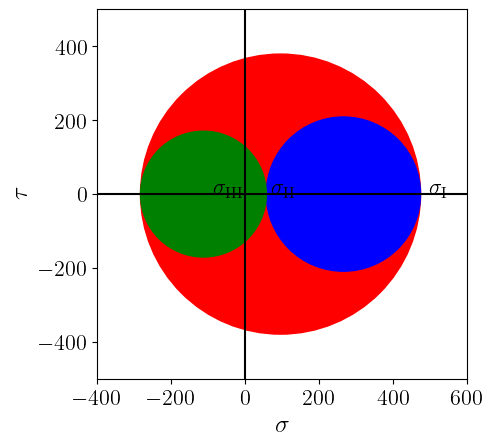

In [45]:
def circleradius(S1,S2):
    s11 = S1; s22 = S2; s12 = 0
    center = [(s11 + s22)/2.0, 0.0]
    radius = np.sqrt((s11 - s22)**2/4.0 + s12**2)
    return center, radius

limits = np.array([[-400,600],[-500,500]])

center1, radius1  = circleradius(sI,sII)
center2, radius2  = circleradius(sI,sIII)
center3, radius3  = circleradius(sII,sIII)

circ1 = plt.Circle((center1[0],0), radius1, facecolor='b', lw=1,edgecolor='b')
circ2 = plt.Circle((center2[0],0), radius2, facecolor='r', lw=1,edgecolor='r')
circ3 = plt.Circle((center3[0],0), radius3, facecolor='g', lw=1,edgecolor='g')

plt.axis('image'); ax = plt.gca()

plt.gcf().gca().add_artist(circ2)
plt.gcf().gca().add_artist(circ1)
plt.gcf().gca().add_artist(circ3)

plt.xlabel(r"$\sigma$", size=18)
plt.ylabel(r"$\tau$", size=18)

plt.text(1.05*sI, 0, r'$\sigma_\mathrm{I}$')
plt.text(1.2*sII, 0, r'$\sigma_\mathrm{II}$')
plt.text(-1.5*sII, 0, r'$\sigma_\mathrm{III}$')

plt.xlim(limits[0,0],limits[0,1])
plt.ylim(limits[1,0],limits[1,1])

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.show()

As deformações principais no plano $x-y$ são dadas pelas seguintes relações geométrias:

\begin{equation*}
\begin{aligned}
\varepsilon_\mathrm{max/min} & =
\frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} \pm\sqrt{ \left( \frac{\varepsilon_{xx} - \varepsilon_{yy}}{2} \right)^2 + \varepsilon_{xy}^2}
\end{aligned}
\end{equation*}

In [46]:
np.set_printoptions(precision=10)
e1 = float(exxP)
e2 = float(eyyP)
e12 = float(exyP)

epsI = (e1+e2)/2 + np.sqrt( ((e1-e2)/2)**2 + e12**2)
epsII = (e1+e2)/2 - np.sqrt( ((e1-e2)/2)**2 + e12**2)
print(' Deformação principal I = ',epsI)
print('Deformação principal II = ',epsII)
Dpric = np.array([[epsI,0],[0,epsII]])
print('Tensor das deformações principal =\n',Dpric)

 Deformação principal I =  0.0027122144504490263
Deformação principal II =  -0.0022122144504490267
Tensor das deformações principal =
 [[ 0.0027122145  0.          ]
 [ 0.           -0.0022122145]]


Tensor das deformações principais vem:

\begin{equation*}
\underline{\underline{\varepsilon}}_\mathrm{P} =
\begin{bmatrix}
\varepsilon_\mathrm{I} & 0 & 0 \\
0 & \varepsilon_\mathrm{II} & 0 \\
0 & 0 & \varepsilon_\mathrm{III} \\
\end{bmatrix} =
\begin{bmatrix}
2.7122 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & -2.2122 \\
\end{bmatrix}\times 10^{-3}
\end{equation*}

**Confirmação tensões principias pela lei de Hooke**

In [47]:
SIp = (2*mu+lam) * epsI +  lam * epsII
print('SIp = ','{:.3f}'.format(SIp),' MPa')
SIIIp = lam * epsI +  (2*mu+lam) * epsII
print('SIIIp = ','{:.3f}'.format(SIIIp),' MPa')
print('\n( SIIp = ','{:.3f}'.format(sVoigt1[2]),' MPa )')

SIp =  474.956  MPa
SIIIp =  -282.648  MPa

( SIIp =  57.692  MPa )


**Direções principais**

In [48]:
def angP(m11,m22,m12): return np.arctan((2*m12)/(m11-m22))

aP1 = angP(e1,e2,e12)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print(f'angPI  = {np.rad2deg(aP1):.3f} deg | {aP1:.3f} radians')
print(f'angPII = {np.rad2deg(aP2):.3f} deg | {aP2:.3f} radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print(f'angPI  =  {np.rad2deg(aPI):.3f} deg | {aPI:.3f} radians')
print(f'angPII = {np.rad2deg(aPII):.3f} deg | {aPII:.3f} radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('nI = ', nI)
nII = MatrTrans[1,:]
print('nII = ', nII)
nIII = MatrTrans[2,:]
print('nIII = ', nIII)

angulos das direções principais

No espaço das tensões:
angPI  = 23.962 deg | 0.418 radians
angPII = 203.962 deg | 3.560 radians

No espaço fisico:
angPI  =  11.981 deg | 0.209 radians
angPII = 101.981 deg | 1.780 radians

Matriz de transformação = 
 [[ 0.9782156073  0.2075914875  0.          ]
 [-0.2075914875  0.9782156073  0.          ]
 [ 0.            0.            1.          ]]

Vetores principais:
nI =  [0.9782156073 0.2075914875 0.          ]
nII =  [-0.2075914875  0.9782156073  0.          ]
nIII =  [0. 0. 1.]


In [51]:
def epsx1(eXX,eYY,gXY,t): return eXX*np.cos(t)**2 + eYY*np.sin(t)**2 + gXY*np.sin(t)*np.cos(t)
def epsy1(eXX,eYY,gXY,t): return eXX*np.sin(t)**2 + eYY*np.cos(t)**2 - gXY*np.sin(t)*np.cos(t)
def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)
def angShearMax(exx,eyy,gxy): return np.arctan( -(exx-eyy)/gxy )


epsXX = float(exxP)
epsYY = float(eyyP)
gamXY = float(exyP)

tang = np.arange(-65,135,1) # unidades: Deg
# extensões normais
extXang = epsx1(epsXX,epsYY,gamXY,np.deg2rad(tang))
extYang = epsy1(epsXX,epsYY,gamXY,np.deg2rad(tang))
# distorção angular
distang = gammax1y1(epsXX,epsYY,gamXY,np.deg2rad(tang))

corteAngP1 = angShearMax(epsXX,epsYY,gamXY)
corteAngP2 = corteAngP1 + np.pi
print('\nNo espaço de Mohr: ---------------------------------------------')
print(f' Ângulo distorção principal I = {np.rad2deg(corteAngP1):.2f} deg)')
print(f'Ângulo distorção principal II = {np.rad2deg(corteAngP2):.2f} deg)')

corteAngPI = corteAngP1/2
corteAngPII = corteAngP2/2
print('\nNo espaço de Mohr: ---------------------------------------------')
print(f' Ângulo distorção principal I = {np.rad2deg(corteAngPI):.2f} deg')
print(f'Ângulo distorção principal II = {np.rad2deg(corteAngPII):.2f} deg')

print('\nExtensões principais: -------------------------------------------')
ePIa = epsx1(epsXX,epsYY,gamXY,aPI)
ePIIa = epsy1(epsXX,epsYY,gamXY,aPI)
dPIa = gammax1y1(epsXX,epsYY,gamXY,aPI)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(aPI)))
print('            Extensão I =','{:.5e}'.format(ePIa))
print('           Extensão II =','{:.5e}'.format(ePIIa))
print('   Distorção de corte  =','{:.1f}'.format(np.abs(dPIa)))

ePIb = epsx1(epsXX,epsYY,gamXY,aPII)
ePIIb = epsy1(epsXX,epsYY,gamXY,aPII)
dPIb = gammax1y1(epsXX,epsYY,gamXY,aPII)
print('\nÂngulo principal (Deg) =','{:.2f}'.format(np.rad2deg(aPII)))
print('            Extensão I =','{:.5e}'.format(ePIb))
print('           Extensão II =','{:.5e}'.format(ePIIb))
print('   Distorção de corte  =','{:.1f}'.format(np.abs(dPIb)))

print('\nDistorções principais: -------------------------------------------')
epsx1ShearPa = epsx1(epsXX,epsYY,gamXY,corteAngPI)
epsy1ShearPa = epsy1(epsXX,epsYY,gamXY,corteAngPI)
cortePa = gammax1y1(epsXX,epsYY,gamXY,corteAngPI)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(corteAngPI)))
print('            Extensão I =','{:.5e}'.format(epsx1ShearPa))
print('           Extensão II =','{:.5e}'.format(np.abs(epsy1ShearPa)))
print('   Distorção principal =','{:.5e}'.format(cortePa))

epsx1ShearPb = epsx1(epsXX,epsYY,gamXY,corteAngPII)
epsy1ShearPb = epsy1(epsXX,epsYY,gamXY,corteAngPII)
cortePb = gammax1y1(epsXX,epsYY,gamXY,corteAngPII)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(corteAngPII)))
print('            Extensão I =','{:.5e}'.format(epsx1ShearPb))
print('           Extensão II =','{:.5e}'.format(np.abs(epsy1ShearPb)))
print('   Distorção principal =','{:.5e}'.format(cortePb))



No espaço de Mohr: ---------------------------------------------
 Ângulo distorção principal I = -77.47 deg)
Ângulo distorção principal II = 102.53 deg)

No espaço de Mohr: ---------------------------------------------
 Ângulo distorção principal I = -38.74 deg
Ângulo distorção principal II = 51.26 deg

Extensões principais: -------------------------------------------
Ângulo principal (Deg) = 11.98
            Extensão I = -2.00915e-03
           Extensão II = 2.50915e-03
   Distorção de corte  = 0.0

Ângulo principal (Deg) = 101.98
            Extensão I = 2.50915e-03
           Extensão II = -2.00915e-03
   Distorção de corte  = 0.0

Distorções principais: -------------------------------------------
Ângulo principal (Deg) = -38.74
            Extensão I = 2.50000e-04
           Extensão II = 2.50000e-04
   Distorção principal = -4.60977e-03
Ângulo principal (Deg) = 51.26
            Extensão I = 2.50000e-04
           Extensão II = 2.50000e-04
   Distorção principal = 4.60977e-03


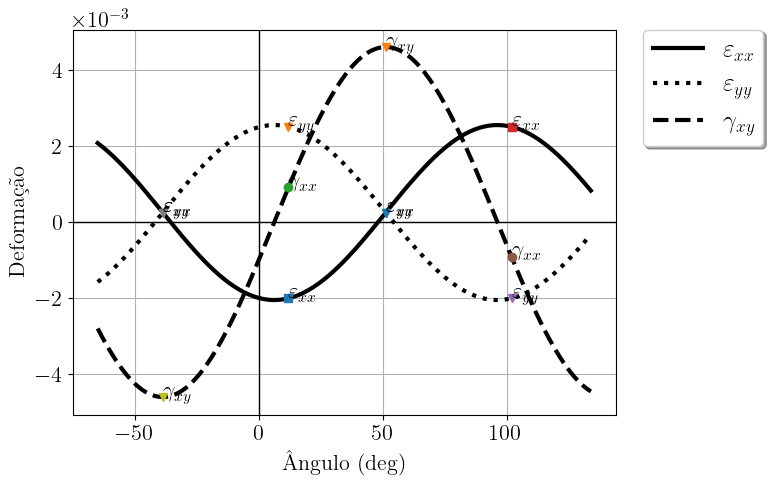

In [50]:

# use LaTeX fonts in the plot
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(tang, extXang, 'k-', label=r'$\varepsilon_{xx}$', linewidth=3)
ax.plot(tang, extYang, 'k:', label=r'$\varepsilon_{yy}$', linewidth=3)
ax.plot(tang, distang, 'k--', label=r'$\gamma_{xy}$', linewidth=3)

ax.plot(np.rad2deg(aPI), ePIa, 's')
ax.text(np.rad2deg(aPI), ePIa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aPI), ePIIa, 'v')
ax.text(np.rad2deg(aPI), ePIIa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aPI), dPIa, 'o')
ax.text(np.rad2deg(aPI), dPIa,r'$\gamma_{xx}$')

ax.plot(np.rad2deg(aPII), ePIb, 's')
ax.text(np.rad2deg(aPII), ePIb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aPII), ePIIb, 'v')
ax.text(np.rad2deg(aPII), ePIIb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aPII), dPIb, 'o')
ax.text(np.rad2deg(aPII), dPIb,r'$\gamma_{xx}$')

ax.plot(np.rad2deg(corteAngPI), epsx1ShearPa, 'v')
ax.text(np.rad2deg(corteAngPI), epsx1ShearPa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(corteAngPI), epsy1ShearPa, 'v')
ax.text(np.rad2deg(corteAngPI), epsy1ShearPa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(corteAngPI), cortePa, 'v')
ax.text(np.rad2deg(corteAngPI), cortePa,r'$\gamma_{xy}$')

ax.plot(np.rad2deg(corteAngPII), epsx1ShearPb, 'v')
ax.text(np.rad2deg(corteAngPII), epsx1ShearPb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(corteAngPII), epsy1ShearPb, 'v')
ax.text(np.rad2deg(corteAngPII), epsy1ShearPb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(corteAngPII), cortePb, 'v')
ax.text(np.rad2deg(corteAngPII), cortePb,r'$\gamma_{xy}$')

plt.ticklabel_format(axis='y',style='sci',scilimits=(1,4))
ax.set(xlabel='Ângulo (deg)', ylabel='Deformação')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>